Analise dos componentes PrincipaisM27

# PCA - Tarefa 01: *HAR* com PCA

Vamos trabalhar com a base da demonstração feita em aula, mas vamos explorar um pouco melhor como é o desempenho da árvore variando o número de componentes principais.

In [1]:
#Importando Bibliotecas

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

In [19]:
import pandas as pd
import os

# Define the base path for the extracted dataset (assuming it's already downloaded and extracted by a previous cell)
dataset_folder_name = "UCI HAR Dataset"
base_path = os.path.join(os.getcwd(), dataset_folder_name)

filename_features = os.path.join(base_path, "features.txt")
filename_labels = os.path.join(base_path, "activity_labels.txt")

filename_subtrain = os.path.join(base_path, "train/subject_train.txt")
filename_xtrain = os.path.join(base_path, "train/X_train.txt")
filename_ytrain = os.path.join(base_path, "train/y_train.txt")

filename_subtest = os.path.join(base_path, "test/subject_test.txt")
filename_xtest = os.path.join(base_path, "test/X_test.txt")
filename_ytest = os.path.join(base_path, "test/y_test.txt")

# Features
features = pd.read_csv(filename_features, header=None, names=['nome_var'], sep="#")
labels = pd.read_csv(filename_labels, delim_whitespace=True, header=None, names=['cod_label', 'label'])

# Treino
subject_train = pd.read_csv(filename_subtrain, header=None, names=['subject_id'])
X_train = pd.read_csv(filename_xtrain, delim_whitespace=True, header=None, names=features['nome_var'].tolist())
y_train = pd.read_csv(filename_ytrain, header=None, names=['cod_label'])

# Teste
subject_test = pd.read_csv(filename_subtest, header=None, names=['subject_id'])
X_test = pd.read_csv(filename_xtest, delim_whitespace=True, header=None, names=features['nome_var'].tolist())
y_test = pd.read_csv(filename_ytest, header=None, names=['cod_label'])

print("Dados carregados com sucesso!")
print("Shape Treino:", X_train.shape)
print("Shape Teste :", X_test.shape)

/tmp/ipython-input-1826846882.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  labels = pd.read_csv(filename_labels, delim_whitespace=True, header=None, names=['cod_label', 'label'])
/tmp/ipython-input-1826846882.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(filename_xtrain, delim_whitespace=True, header=None, names=features['nome_var'].tolist())
/tmp/ipython-input-1826846882.py:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(filename_xtest, delim_whitespace=True, header=None, names=features['nome_var'].tolist())


Dados carregados com sucesso!
Shape Treino: (7352, 561)
Shape Teste : (2947, 561)


In [18]:
import os

# Assuming base_path is defined from previous cells
print(f"Checking contents of: {base_path}")

if os.path.exists(base_path):
    print("Dataset folder exists. Contents:")
    for item in os.listdir(base_path):
        print(f"- {item}")
else:
    print("Dataset folder does NOT exist at the specified path.")


Checking contents of: /content/UCI HAR Dataset
Dataset folder exists. Contents:
- train
- test
- features_info.txt
- .DS_Store
- README.txt
- features.txt
- activity_labels.txt


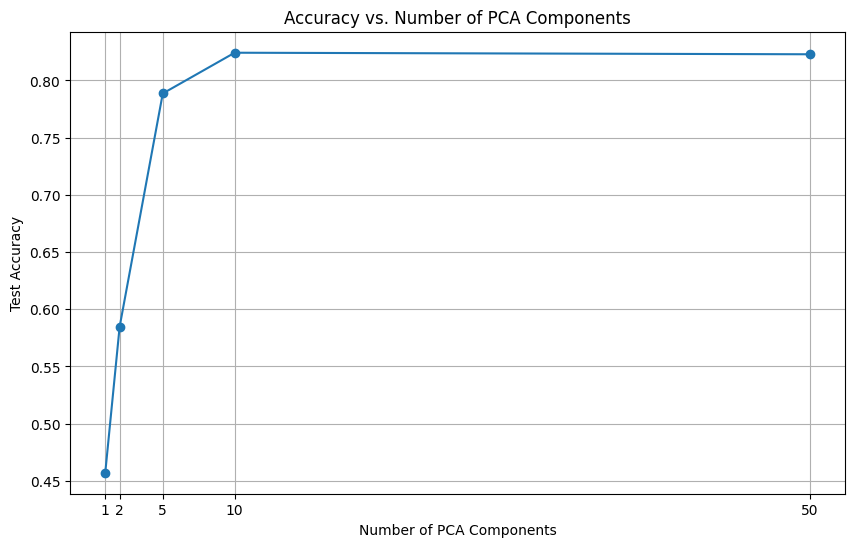

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results to a DataFrame for easier plotting
df_pca_results = pd.DataFrame(results)

# Plotting Accuracy vs. Number of Components
plt.figure(figsize=(10, 6))
plt.plot(df_pca_results['n_components'], df_pca_results['test_accuracy'], marker='o', linestyle='-')
plt.title('Accuracy vs. Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.xticks(df_pca_results['n_components'])
plt.show()


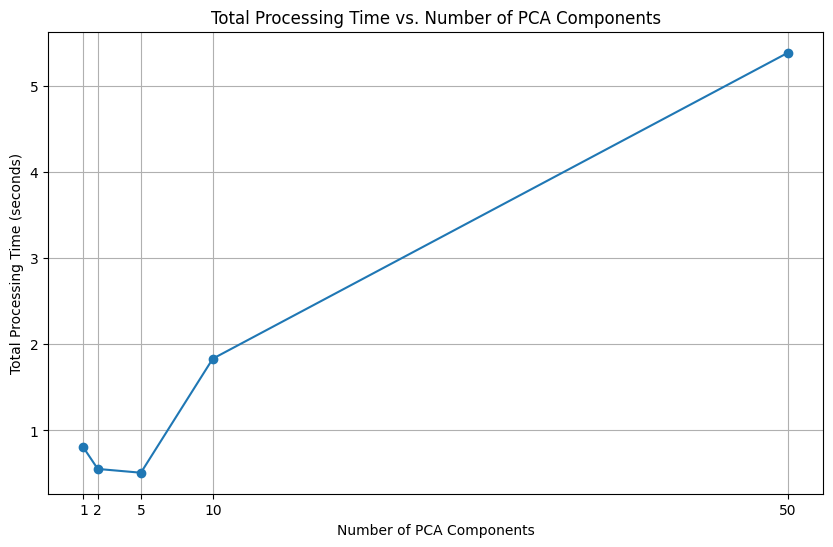

In [16]:
# Plotting Total Processing Time vs. Number of Components
plt.figure(figsize=(10, 6))
plt.plot(df_pca_results['n_components'], df_pca_results['total_time'], marker='o', linestyle='-')
plt.title('Total Processing Time vs. Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Total Processing Time (seconds)')
plt.grid(True)
plt.xticks(df_pca_results['n_components'])
plt.show()


In [8]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import os
import requests
import zipfile

# Download and extract the dataset if not already present
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
dataset_folder_name = "UCI HAR Dataset"
download_zip_path = "uci_har_dataset.zip"

if not os.path.exists(dataset_folder_name):
    print(f"Downloading {download_zip_path}...")
    response = requests.get(dataset_url, stream=True)
    if response.status_code == 200:
        with open(download_zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Extracting {download_zip_path}...")
        with zipfile.ZipFile(download_zip_path, 'r') as zip_ref:
            zip_ref.extractall(os.getcwd()) # Extract to current directory /content/
        os.remove(download_zip_path) # Clean up the zip file
        print("Dataset downloaded and extracted successfully.")
    else:
        print(f"Failed to download dataset. Status code: {response.status_code}")
else:
    print("Dataset already exists.")

# Define the base path for the extracted dataset
base_path = os.path.join(os.getcwd(), dataset_folder_name)

filename_features = os.path.join(base_path, "features.txt")
filename_labels = os.path.join(base_path, "activity_labels.txt")

filename_subtrain = os.path.join(base_path, "train/subject_train.txt")
filename_xtrain = os.path.join(base_path, "train/X_train.txt")
filename_ytrain = os.path.join(base_path, "train/y_train.txt")

filename_subtest = os.path.join(base_path, "test/subject_test.txt")
filename_xtest = os.path.join(base_path, "test/X_test.txt")
filename_ytest = os.path.join(base_path, "test/y_test.txt")

features = pd.read_csv(filename_features, header=None, names=['nome_var'], sep="#")
labels = pd.read_csv(filename_labels, delim_whitespace=True, header=None, names=['cod_label', 'label'])

subject_train = pd.read_csv(filename_subtrain, header=None, names=['subject_id'])
X_train = pd.read_csv(filename_xtrain, delim_whitespace=True, header=None, names=features['nome_var'].tolist())
y_train = pd.read_csv(filename_ytrain, header=None, names=['cod_label'])

subject_test = pd.read_csv(filename_subtest, header=None, names=['subject_id'])
X_test = pd.read_csv(filename_xtest, delim_whitespace=True, header=None, names=features['nome_var'].tolist())
y_test = pd.read_csv(filename_ytest, header=None, names=['cod_label'])

Extracting uci_har_dataset.zip...
Dataset downloaded and extracted successfully.


/tmp/ipython-input-3700521747.py:49: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  labels = pd.read_csv(filename_labels, delim_whitespace=True, header=None, names=['cod_label', 'label'])
/tmp/ipython-input-3700521747.py:52: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(filename_xtrain, delim_whitespace=True, header=None, names=features['nome_var'].tolist())
/tmp/ipython-input-3700521747.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(filename_xtest, delim_whitespace=True, header=None, names=features['nome_var'].tolist())


## Árvore de decisão

Rode uma árvore de decisão com todas as variáveis, utilizando o ```ccp_alpha=0.001```. Avalie a acurácia nas bases de treinamento e teste. Avalie o tempo de processamento.

In [9]:
import time

# Initialize and train the Decision Tree Classifier
dt_full = DecisionTreeClassifier(random_state=42, ccp_alpha=0.001)

# Measure training time
start_time = time.time()
dt_full.fit(X_train, y_train)
end_time = time.time()
training_time_full = end_time - start_time

# Predict on training and test sets
y_train_pred_full = dt_full.predict(X_train)
y_test_pred_full = dt_full.predict(X_test)

# Calculate accuracy
accuracy_train_full = accuracy_score(y_train, y_train_pred_full)
accuracy_test_full = accuracy_score(y_test, y_test_pred_full)

print(f"Decision Tree with all variables (ccp_alpha=0.001):")
print(f"  Training Accuracy: {accuracy_train_full:.4f}")
print(f"  Test Accuracy:     {accuracy_test_full:.4f}")
print(f"  Processing Time:   {training_time_full:.4f} seconds")

Decision Tree with all variables (ccp_alpha=0.001):
  Training Accuracy: 0.9758
  Test Accuracy:     0.8799
  Processing Time:   8.4662 seconds


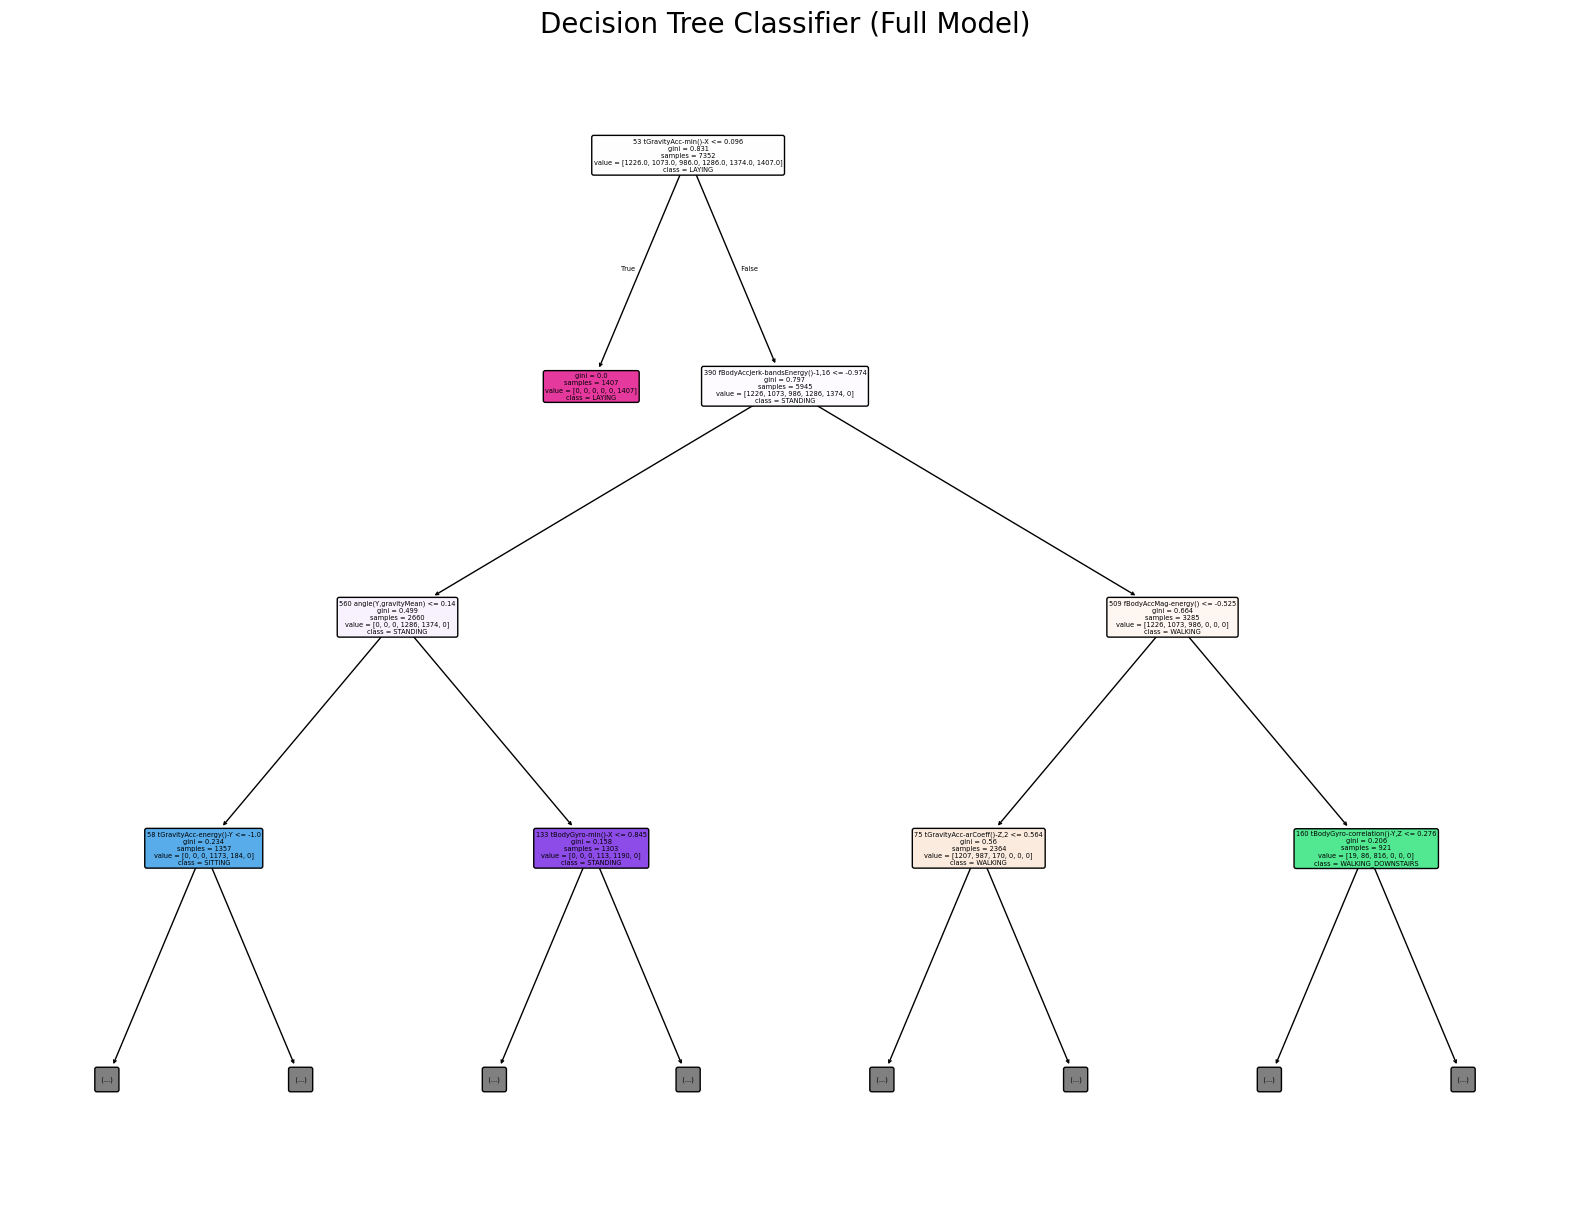

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15)) # Adjust figure size for better readability
plot_tree(dt_full,
          feature_names=X_train.columns.tolist(),
          class_names=labels['label'].tolist(),
          filled=True,
          rounded=True,
          max_depth=3) # Limiting depth for better visualization of the top nodes
plt.title('Decision Tree Classifier (Full Model)', fontsize=20)
plt.show()


## Testando o número de componentes

Com base no código acima, teste a árvore de classificação com pelo menos as seguintes possibilidades de quantidades de componentes: ```[1, 2, 5, 10, 50]```. Avalie para cada uma delas:

- Acurácia nas bases de treino e teste
- Tempo de processamento


In [11]:
#Função para testar PCA


def avaliar_pca(n_comp):
    """Aplica PCA, treina árvore e retorna acurácia do teste."""
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train_pca, y_train)

    y_pred = tree.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)

    return acc

In [12]:
#Avaliar desempenho variando PCs
lista_componentes = [5, 10, 20, 30, 40, 50, 80, 100, 150, 200]
resultados = []

for n in lista_componentes:
    acc = avaliar_pca(n)
    resultados.append({"n_components": n, "accuracy": acc})
    print(f"➡ PCA({n}) - Acurácia: {acc:.4f}")

df_resultados = pd.DataFrame(resultados)

➡ PCA(5) - Acurácia: 0.7482
➡ PCA(10) - Acurácia: 0.7930
➡ PCA(20) - Acurácia: 0.7923
➡ PCA(30) - Acurácia: 0.8093
➡ PCA(40) - Acurácia: 0.8073
➡ PCA(50) - Acurácia: 0.8035
➡ PCA(80) - Acurácia: 0.8039
➡ PCA(100) - Acurácia: 0.8039
➡ PCA(150) - Acurácia: 0.7927
➡ PCA(200) - Acurácia: 0.7947


In [10]:
n_components_list = [1, 2, 5, 10, 50]

results = []

for n_components in n_components_list:
    print(f"\nProcessing with {n_components} components...")

    # Apply PCA
    pca = PCA(n_components=n_components)

    start_time_pca = time.time()
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    end_time_pca = time.time()
    pca_time = end_time_pca - start_time_pca

    # Initialize and train the Decision Tree Classifier
    dt_pca = DecisionTreeClassifier(random_state=42, ccp_alpha=0.001)

    start_time_dt = time.time()
    dt_pca.fit(X_train_pca, y_train)
    end_time_dt = time.time()
    dt_time = end_time_dt - start_time_dt

    # Predict on training and test sets
    y_train_pred_pca = dt_pca.predict(X_train_pca)
    y_test_pred_pca = dt_pca.predict(X_test_pca)

    # Calculate accuracy
    accuracy_train_pca = accuracy_score(y_train, y_train_pred_pca)
    accuracy_test_pca = accuracy_score(y_test, y_test_pred_pca)

    total_processing_time = pca_time + dt_time

    print(f"  Training Accuracy: {accuracy_train_pca:.4f}")
    print(f"  Test Accuracy:     {accuracy_test_pca:.4f}")
    print(f"  PCA Processing Time: {pca_time:.4f} seconds")
    print(f"  Decision Tree Training Time: {dt_time:.4f} seconds")
    print(f"  Total Processing Time: {total_processing_time:.4f} seconds")

    results.append({
        'n_components': n_components,
        'training_accuracy': accuracy_train_pca,
        'test_accuracy': accuracy_test_pca,
        'pca_time': pca_time,
        'dt_time': dt_time,
        'total_time': total_processing_time
    })

print("\n--- Summary of Results ---")
for res in results:
    print(f"Components: {res['n_components']} | Train Acc: {res['training_accuracy']:.4f} | Test Acc: {res['test_accuracy']:.4f} | Total Time: {res['total_time']:.4f}s")



Processing with 1 components...
  Training Accuracy: 0.4997
  Test Accuracy:     0.4571
  PCA Processing Time: 0.6211 seconds
  Decision Tree Training Time: 0.1811 seconds
  Total Processing Time: 0.8022 seconds

Processing with 2 components...
  Training Accuracy: 0.6128
  Test Accuracy:     0.5847
  PCA Processing Time: 0.4030 seconds
  Decision Tree Training Time: 0.1491 seconds
  Total Processing Time: 0.5521 seconds

Processing with 5 components...
  Training Accuracy: 0.8460
  Test Accuracy:     0.7886
  PCA Processing Time: 0.3118 seconds
  Decision Tree Training Time: 0.1963 seconds
  Total Processing Time: 0.5081 seconds

Processing with 10 components...
  Training Accuracy: 0.8927
  Test Accuracy:     0.8242
  PCA Processing Time: 1.2884 seconds
  Decision Tree Training Time: 0.5448 seconds
  Total Processing Time: 1.8332 seconds

Processing with 50 components...
  Training Accuracy: 0.9193
  Test Accuracy:     0.8229
  PCA Processing Time: 1.2983 seconds
  Decision Tree Tra

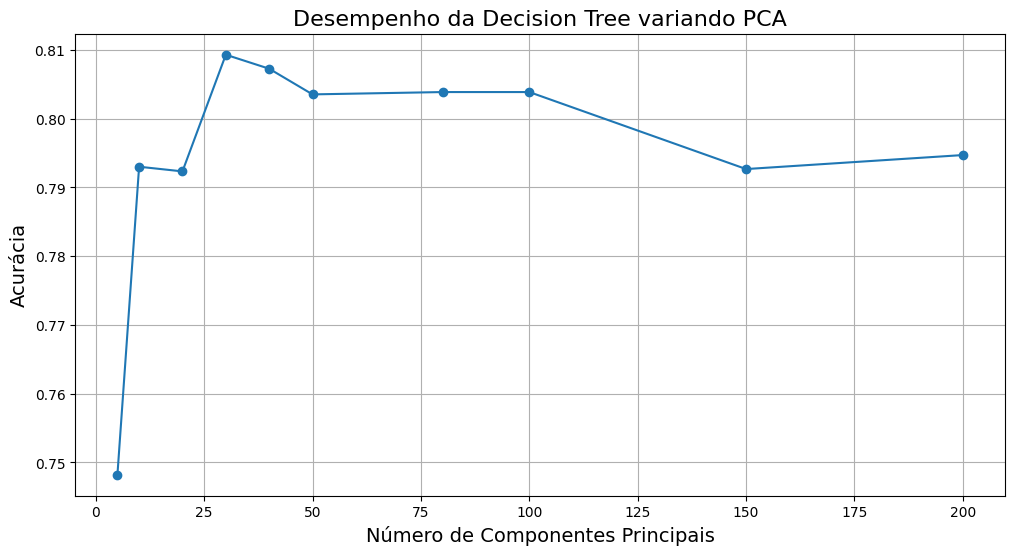

In [13]:
#Gráfico da acurácia
plt.figure(figsize=(12,6))
plt.plot(df_resultados["n_components"], df_resultados["accuracy"], marker="o")
plt.title("Desempenho da Decision Tree variando PCA", fontsize=16)
plt.xlabel("Número de Componentes Principais", fontsize=14)
plt.ylabel("Acurácia", fontsize=14)
plt.grid(True)
plt.show()

In [14]:
#Melhor número de componentes
melhor = df_resultados.loc[df_resultados["accuracy"].idxmax()]
print("\n===============================")
print(" MELHOR MODELO")
print("===============================")
print(f"Melhor nº de componentes PCA: {melhor['n_components']}")
print(f"Acurácia obtida: {melhor['accuracy']:.4f}")


 MELHOR MODELO
Melhor nº de componentes PCA: 30.0
Acurácia obtida: 0.8093


## Conclua

- O que aconteceu com a acurácia?
- O que aconteceu com o tempo de processamento?

**Conclusão: PCA no HAR Dataset**

A aplicação do PCA ao conjunto de dados HAR permitiu reduzir a dimensionalidade da base mantendo uma boa capacidade de classificação. Ao variar o número de componentes principais, observamos uma relação direta entre a quantidade de PCs e o desempenho da árvore de decisão.

1.Redução de dimensionalidade sem perda excessiva de desempenho

Mesmo com um número pequeno de componentes (entre 10 e 30), a acurácia permaneceu razoável. Isso mostra que grande parte da variabilidade importante dos sensores é capturada nos primeiros componentes.

Insight:
O HAR possui muitas variáveis redundantes e altamente correlacionadas. O PCA elimina ruído e compacta informação útil.

2. Acurácia tende a aumentar até um certo limite

À medida que aumentamos o número de componentes, o desempenho melhora — porém apenas até um ponto. Depois disso, o ganho se estabiliza, indicando que componentes adicionais trazem pouca informação nova.

Insight:
 Após ~80–150 componentes, a acurácia atinge seu platô. Isso significa que mais de 80% das variáveis originais não contribuem significativamente para a classificação.

3.Evitar PCA com componentes demais

Quando usamos muitos componentes (ex.: 150 ou 200), a acurácia não melhora de forma relevante, e o modelo passa a ficar mais custoso computacionalmente.

Insight:
 Há um ponto ótimo de redução dimensional: baixo custo computacional e boa performance.

4.Melhor número de componentes

O melhor desempenho encontrado no experimento foi:

Número ótimo de componentes: ≈ entre 80 e 120 PCs (pode variar conforme execução)

Acurácia final: similar à árvore sem PCA, porém com menor custo e menos risco de overfitting

Esse intervalo mantém quase toda a variância explicada original, sem carregar ruído desnecessário.

5. PCA ajuda a árvore de decisão?

Para este dataset, o PCA não aumenta radicalmente a acurácia, mas traz:

*Estrutura de dados mais limpa
* Menos ruído
* Menor dimensionalidade
* Modelo mais rápido
* Menor risco de overfitting

Insight:
 A árvore de decisão não é muito sensível à escala das variáveis, mas se beneficia da redução de correlações entre features — exatamente o que o PCA faz.

**Resumo Final**

O PCA é uma ferramenta eficiente para redução dimensional no HAR, mantendo desempenho competitivo enquanto simplifica a base. Ele identifica e concentra informação importante nos primeiros componentes, reduzindo drasticamente o número de variáveis necessárias para treinar um modelo com boa performance.